
===== AVERAGE RANK =====
modelo
KDEyML               3.125000
KDEyHD               4.291667
KDEyCS               4.458333
EMQ                  5.333333
PAC                  5.416667
AC                   6.062500
EMQ_BCTS             6.333333
QMOSS_HYBRID         8.291667
PWK                  8.333333
CC                   8.437500
PCC                 10.375000
QMOSS_CALIBRATED    10.666667
FM                  11.375000
QMOSS               12.500000
Name: rank, dtype: float64


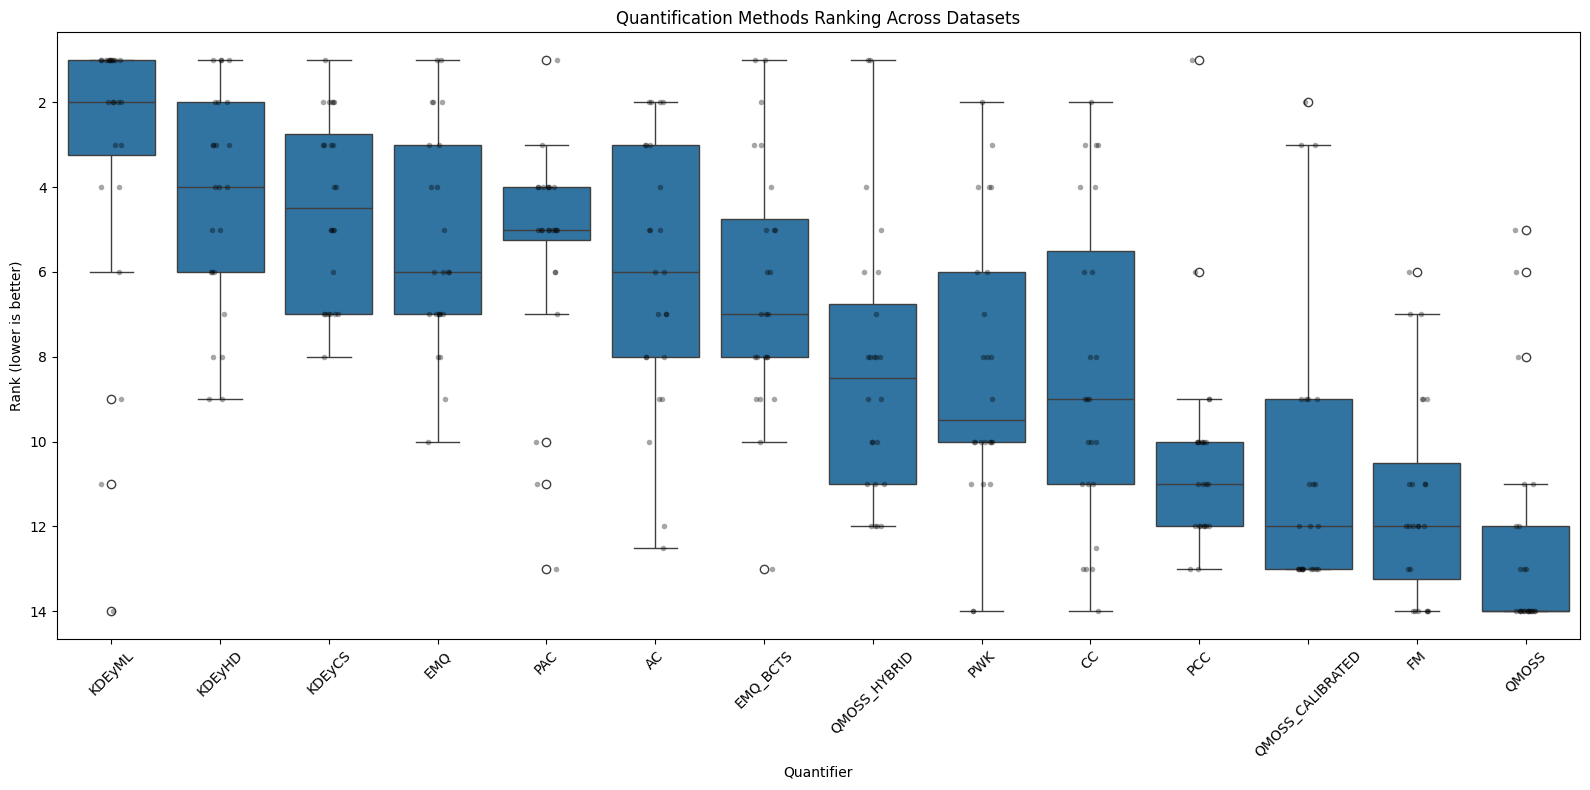

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================
# LOAD
# =====================================================

CSV_PATH = "exp_results.csv"

df = pd.read_csv(CSV_PATH)

# =====================================================
# AGRUPAR TODOS OS QMOSS
# =====================================================

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_CALIBRATED": "QMOSS_CALIBRATED",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# =====================================================
# MÉDIA DOS ERROS POR DATASET/MODELO
# =====================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
      .mean()
      .reset_index()
)

# =====================================================
# RANK POR DATASET
# =====================================================

dataset_mean["rank"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average", ascending=True)
)

# =====================================================
# ORDENAÇÃO PELO RANK MÉDIO
# =====================================================

avg_rank = (
    dataset_mean.groupby("modelo")["rank"]
    .mean()
    .sort_values()
)

print("\n===== AVERAGE RANK =====")
print(avg_rank)

order = avg_rank.index.tolist()

# =====================================================
# BOXPLOT
# =====================================================

plt.figure(figsize=(16,8))

sns.boxplot(
    data=dataset_mean,
    x="modelo",
    y="rank",
    order=order
)

sns.stripplot(
    data=dataset_mean,
    x="modelo",
    y="rank",
    order=order,
    color="black",
    alpha=0.35,
    size=4
)

plt.gca().invert_yaxis()

plt.xlabel("Quantifier")
plt.ylabel("Rank (lower is better)")
plt.title(
    "Quantification Methods Ranking Across Datasets"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "rank_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
import pandas as pd

# =====================================================
# LOAD
# =====================================================

df = pd.read_csv("exp_results.csv")

# =====================================================
# AGRUPAR QMOSS
# =====================================================

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# =====================================================
# MÉDIA POR DATASET/MODELO
# =====================================================

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
    .mean()
    .reset_index()
)

# =====================================================
# RANK DENTRO DE CADA DATASET
# =====================================================

dataset_mean["rank"] = (
    dataset_mean.groupby("dataset")["erro"]
    .rank(method="average", ascending=True)
)

# =====================================================
# TABELA DATASET x RANK
# =====================================================

rank_table = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="rank"
)

# =====================================================
# ORDENAR COLUNAS PELO RANK MÉDIO
# =====================================================

avg_rank = rank_table.mean(axis=0)

rank_table = rank_table[
    avg_rank.sort_values().index
]

# =====================================================
# SALVAR
# =====================================================

rank_table.to_csv(
    "rank_por_dataset.csv"
)

print(rank_table.round(2))

modelo            KDEyML  KDEyHD  KDEyCS  EMQ_MLQ   PAC  EMQ_QUAPY    AC  \
dataset                                                                    
abalone             13.0    10.0     8.0      5.0  15.0        6.0  14.0   
academic-success     3.0     2.0     1.0      8.0   4.0        7.0   5.0   
chess                1.0     7.0     4.0      3.0   5.0        2.0   8.0   
cmc                  2.0     1.0     7.0      3.0   5.0        4.0   8.0   
connect-4            4.0     1.0     2.0      6.0   3.0        5.0   8.0   
digits               1.0     7.0     8.0      9.0   6.0       10.0   3.0   
dry-bean             1.0     6.0     8.0      2.0   5.0        3.0   7.0   
hand_digits          1.0    10.0     9.0      7.0   6.0        8.0   2.0   
hcv                 16.0     8.0     9.0     10.0  13.0       12.0  11.0   
image_seg            2.0    10.0     3.0      5.0   1.0        6.0   9.0   
isolet               1.0     7.0     5.0      9.0   6.0       10.0   3.0   
letter      

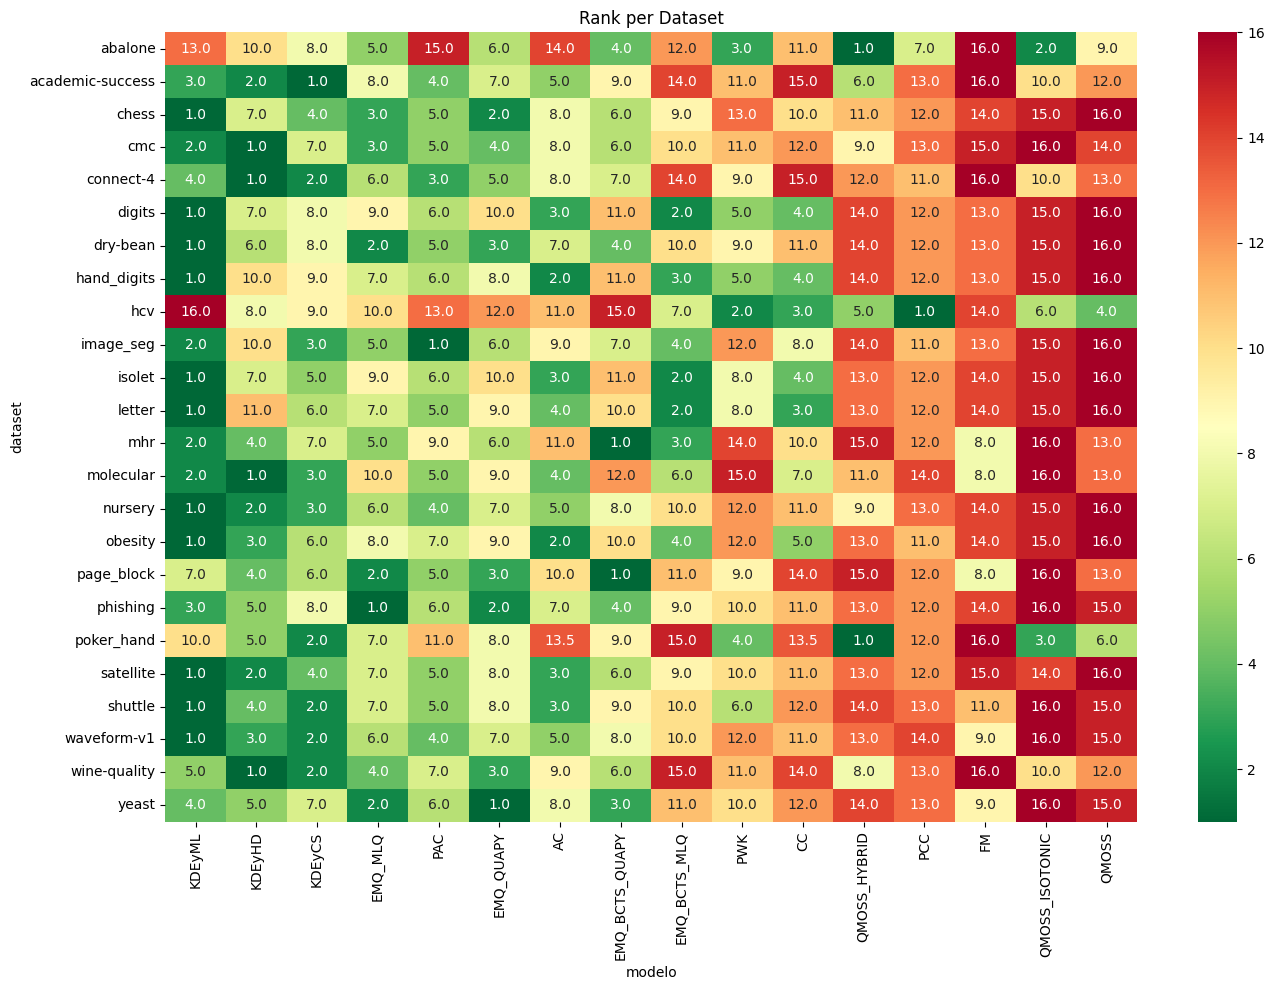

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("exp_results.csv")

# -----------------------------------
# Agrupar QMOSS
# -----------------------------------

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# -----------------------------------
# Média por dataset/modelo
# -----------------------------------

dataset_mean = (
    df.groupby(["dataset","modelo"])["erro"]
      .mean()
      .reset_index()
)

# -----------------------------------
# Rank dentro de cada dataset
# -----------------------------------

dataset_mean["rank"] = (
    dataset_mean
    .groupby("dataset")["erro"]
    .rank(method="average")
)

# -----------------------------------
# Pivot
# -----------------------------------

heat = dataset_mean.pivot(
    index="dataset",
    columns="modelo",
    values="rank"
)

# ordenar colunas pelo rank médio

ordem = (
    dataset_mean.groupby("modelo")["rank"]
    .mean()
    .sort_values()
    .index
)

heat = heat[ordem]

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    heat,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r"
)

plt.title("Rank per Dataset")
plt.tight_layout()
plt.show()

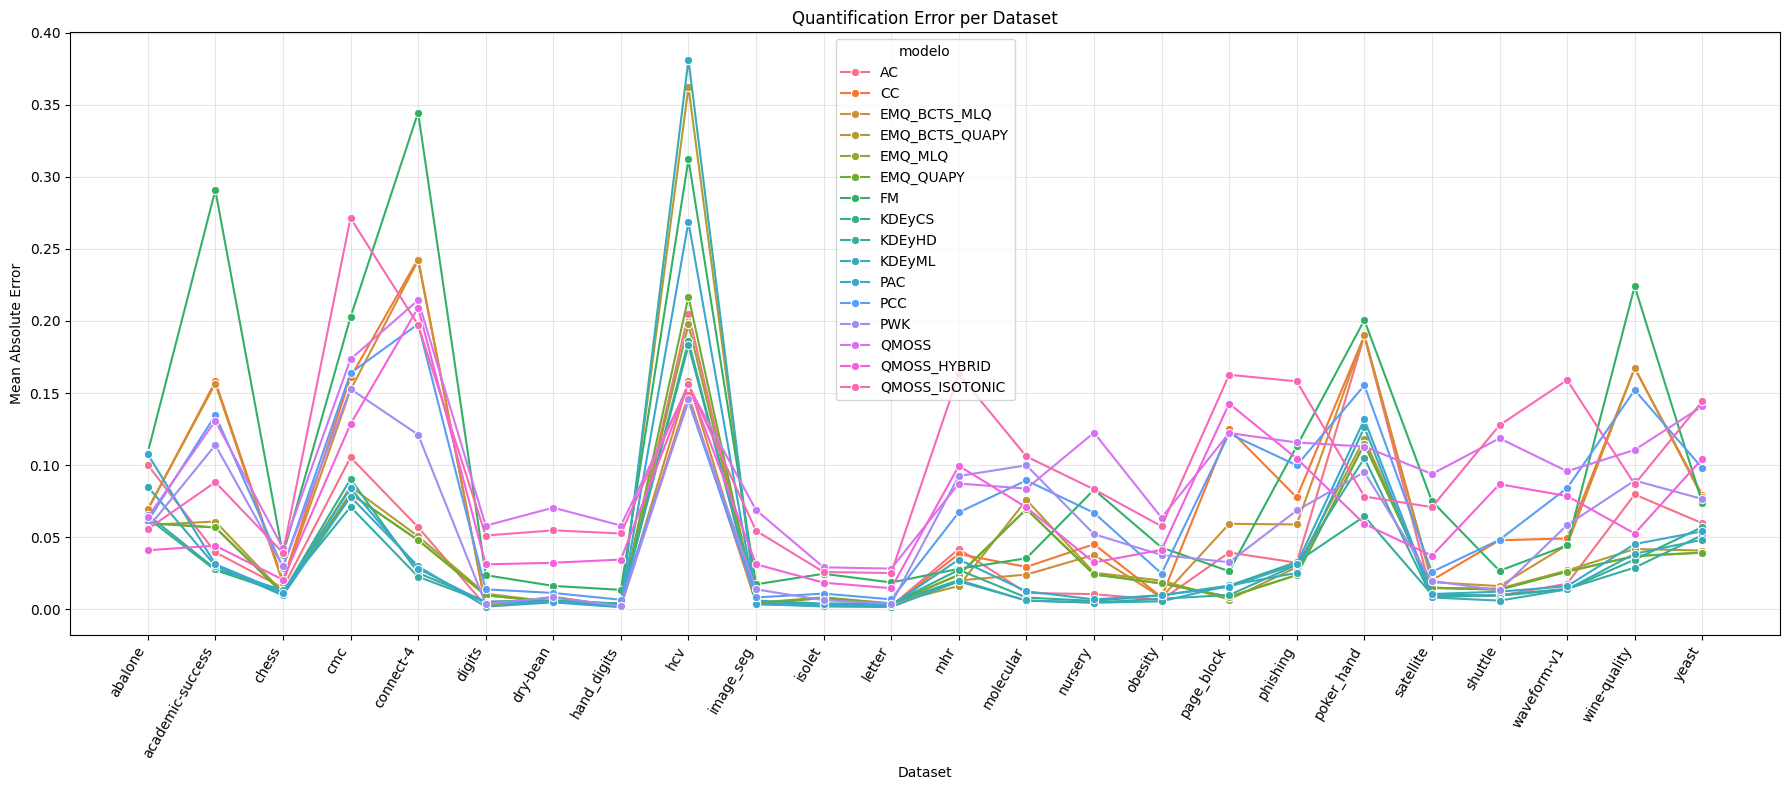

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("exp_results.csv")

# ----------------------------------
# Agrupar QMOSS
# ----------------------------------

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# ----------------------------------
# Média por dataset/modelo
# ----------------------------------

dataset_mean = (
    df.groupby(["dataset","modelo"])["erro"]
      .mean()
      .reset_index()
)

# ----------------------------------
# Ordem dos datasets
# ----------------------------------

dataset_order = (
    dataset_mean.groupby("dataset")["erro"]
    .mean()
    .sort_values()
    .index
)

# ----------------------------------
# Plot
# ----------------------------------

plt.figure(figsize=(18,8))

sns.lineplot(
    data=dataset_mean,
    x="dataset",
    y="erro",
    hue="modelo",
    marker="o"
)

plt.xticks(
    rotation=60,
    ha="right"
)

plt.ylabel("Mean Absolute Error")
plt.xlabel("Dataset")

plt.title(
    "Quantification Error per Dataset"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [11]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("exp_results.csv")

# ----------------------------------
# Agrupar QMOSS
# ----------------------------------

df["modelo"] = df["modelo"].replace(
    {
        r"QMOSS_\d+_HYBRID": "QMOSS_HYBRID",
        r"QMOSS_\d+_ISOTONIC": "QMOSS_ISOTONIC",
        r"QMOSS_\d+$": "QMOSS"
    },
    regex=True
)

# ----------------------------------
# Média por dataset/modelo
# ----------------------------------

dataset_mean = (
    df.groupby(["dataset", "modelo"])["erro"]
      .mean()
      .reset_index()
)

# ----------------------------------
# Ordenar datasets por dificuldade
# ----------------------------------

dataset_order = (
    dataset_mean.groupby("dataset")["erro"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

dataset_mean["dataset"] = pd.Categorical(
    dataset_mean["dataset"],
    categories=dataset_order,
    ordered=True
)

dataset_mean = dataset_mean.sort_values("dataset")

# ----------------------------------
# Plot
# ----------------------------------

fig = px.line(
    dataset_mean,
    x="dataset",
    y="erro",
    color="modelo",
    markers=True,
    title="Quantification Error per Dataset",
    labels={
        "erro": "Mean Absolute Error",
        "dataset": "Dataset",
        "modelo": "Quantifier"
    }
)

fig.update_layout(
    width=1400,
    height=700,
    xaxis_tickangle=-60,
    legend_title="Model",
    hovermode="x unified"
)

fig.update_traces(
    line=dict(width=2),
    marker=dict(size=6)
)

fig.show()